# 🤖 Stateful, Cyclic Self-Healing AI Agent for Competitive Programming

---

## 📌 Overview

This is a **self-healing AI agent** that autonomously solves [Codeforces](https://codeforces.com/) competitive programming problems. The agent is built using **LangGraph**

The core idea is simple: instead of asking an LLM to solve a problem once and hoping for the best, our agent:
1. **Reads** the problem
2. **Plans** an algorithm
3. **Writes** code
4. **Tests** it locally against sample inputs
5. **Heals** debugs and rewrites (if the code fails — up to 3 times)
6. **Remembers** its past attempt and use it to heal itself

This cycle is what makes the agent *self-healing* and *stateful*.

---

## 🗺️ Architectural Flow

Below is the high-level flow of the agent. Each box is a **node** in the LangGraph state machine.

```
┌─────────┐     ┌─────────┐      ┌──────────┐     ┌─────┐      ┌──────────┐
│  fetch  │────▶│ analyze │────▶│   code   │────▶│ run │────▶│ evaluate │
└─────────┘     └─────────┘      └──────────┘     └─────┘      └──────────┘
                                                                    │
                                                          ┌─────────┴──────────┐
                                                          │                    │
                                                       passed?              failed?
                                                          │                    │
                                                         END              ┌────────┐
                                                                          │  heal  │──────┐
                                                                          └────────┘      │
                                                                               ▲          │
                                                                               └────run◀──┘
```

### Node Descriptions

| Node | What it does |
|------|--------------|
| `fetch` | Loads the problem from a local JSON cache (title, statement, sample tests) |
| `analyze` | Uses an LLM to understand the problem and design an algorithm |
| `code` | Uses an LLM to write a complete C++/Python solution |
| `run` | Compiles and runs the code against sample test cases locally |
| `evaluate` | Decides: did we pass? If not, have we exceeded max attempts? |
| `heal` | Uses a stronger LLM to debug and rewrite the broken code |

---

## 🧠 Key Design Decisions

- **Two-tier LLM strategy**: A cheaper/faster model (`gemini-3.1-flash-lite`) writes the first solution. A stronger model (`gemini-3.5-flash`) is used for healing, especially on harder problems.
- **Local execution**: Code is compiled and run in a subprocess with a 2-second timeout per test — no external judge needed.
- **Max 3 healing attempts**: To avoid infinite loops, the agent gives up after 3 failed rewrites.
- **API bottleneck handling:** The batch runner is designed to tolerate temporary API bottlenecks such as quota spikes, `rate limits`,`429` and `503 UNAVAILABLE` responses caused by high demand. When such transient errors occur, the system waits for a cooldown period and retries the same question, which prevents unnecessary crashes and reduces lost progress during long runs on the free API tier.

---

## 📋 Selected Codeforces Problems

The agent was evaluated on a selected subset from the provided Google Sheet containing Codeforces problem URLs and ratings. A few representative problems are listed below.

| # | Problem ID | Rating | Link |
|---|---|---:|---|
| 1 | 1511C | 1100 | [Codeforces 1511C](https://codeforces.com/problemset/problem/1511/C) |
| 2 | 414B | 1400 | [Codeforces 414B](https://codeforces.com/problemset/problem/414/B) |
| 3 | 845C | 1500 | [Codeforces 845C](https://codeforces.com/problemset/problem/845/C) |
| 4 | 1516C | 1700 | [Codeforces 1516C](https://codeforces.com/problemset/problem/1516/C) |

> Source: [Google Sheet](https://docs.google.com/spreadsheets/d/1uNGBa9pOZQCDM1hmzYZiA-ss8o3zOvW5gyEo3oPY5-8/edit?gid=0#gid=0)
---

## ⚙️ Step 1: Install Dependencies

We need four main libraries:
- **`langgraph`** — for building the stateful agent graph
- **`langchain-core`** — message types and LLM abstractions
- **`langchain-google-genai`** — Google Gemini LLM connector

In [1]:
!pip install -qU langgraph langchain-core langchain-google-genai

## 🔑 Step 2: Configure API Key

We load the `GOOGLE_API_KEY` key from Colab's secret store.

In [2]:
import os
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

## 🤖 Step 3: Set Up the LLMs

We use **two different Gemini models**:
- `gemini-3.1-flash-lite` — fast and cheap, used for the first solution attempt
- `gemini-3.5-flash` — stronger, used when debugging hard problems or retrying

This two-tier approach saves API cost while still having a powerful fallback.

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

def get_llm():
    # cheaper model for first-pass code generation
    return ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

def get_healing_llm():
    # stronger model for debugging / self-heal
    return ChatGoogleGenerativeAI(model="gemini-3.5-flash")

## 📦 Step 4: Define the Agent State

The `AgentState` is the **memory** of our agent — a typed dictionary that gets passed between every node in the graph. Think of it as a shared whiteboard that all steps can read from and write to.

Key fields:
- `problem_statement`, `plan`, `code` — the problem and solution at each stage
- `test_cases`, `run_result`, `error_logs` — for the execution/testing loop
- `attempt_count` — tracks how many healing attempts we've made
- `status` — the current stage of the pipeline (`pending` → `planning` → `coding` → `testing` → `done`)

In [4]:
from typing import TypedDict, List, Literal, Optional, Dict, Any, Annotated
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict, total=False):
    # Input metadata
    problem_url: str
    problem_id: str
    difficulty: int
    language: Literal["cpp", "python"]

    # Problem understanding
    problem_title: str
    problem_statement: str
    constraints: str
    plan: str

    # Code generation + execution
    code: str
    test_cases: List[Dict[str, str]]
    run_result: Dict[str, Any]
    error_logs: str

    # Memory / trace
    messages: Annotated[List[BaseMessage], add_messages]

    # Control / bookkeeping
    attempt_count: int
    status: Literal["pending", "planning", "coding", "testing", "healing", "done", "failed"]

## 💾 Step 5: Load Problem Cache

Instead of scraping Codeforces live (which was blocked), we loaded problems(using `scrape.py`) into a `cf_problems.json` file. This function looks up a problem by its URL and returns its data instantly.

In [5]:
import json

with open("cf_problems.json", "r", encoding="utf-8") as f:
    PROBLEM_LIST = json.load(f)

# Map by problem URL for fast lookup
PROBLEMS_BY_URL = {p["url"]: p for p in PROBLEM_LIST}

def get_problem_from_cache(url: str) -> dict:
    return PROBLEMS_BY_URL[url]

## 🔧 Step 6: Build the Agent Nodes

Each function below is one **node** in our LangGraph pipeline. Every node receives the current `AgentState` and returns a dictionary of fields to update.

### Node 1: `fetch_node` — Load the Problem
Reads problem data from the cache and populates the state with the title, statement, constraints, and sample test cases.

In [6]:
def fetch_node(state: AgentState) -> dict:
    url = state["problem_url"]
    data = get_problem_from_cache(url)

    samples = []
    for s in data.get("samples", []):
        samples.append({
            "input": s.get("input", ""),
            "expected_output": s.get("expected_output", s.get("output", "")),
        })

    return {
        "problem_title": data.get("title", ""),
        "problem_statement": data.get("statement", ""),
        "constraints": data.get("constraints", ""),
        "test_cases": samples,
        "status": "planning",
        "attempt_count": state.get("attempt_count", 0),
        "messages": [
            HumanMessage(content=f"Loaded problem {data.get('title', '')} from cache for URL {url}")
        ],
    }

### Node 2: `analyze_node` — Understand and Plan

The LLM acts as a **competitive programming coach**. It reads the problem and produces:
- A short restatement of the task
- Key constraints
- The problem type (greedy, DP, graph, etc.)
- A step-by-step algorithm
- Time/memory complexity
- Edge cases to watch out for

This planning step significantly improves code quality compared to asking the LLM to write code directly.

In [7]:
from langchain_core.messages import SystemMessage, HumanMessage

def llm_to_text(res):
    """Helper to extract plain text from various LLM response formats."""
    if hasattr(res, "text") and res.text is not None:
        return str(res.text)
    if hasattr(res, "content"):
        if isinstance(res.content, str):
            return res.content
        return str(res.content)
    return str(res)

def analyze_node(state: AgentState) -> Dict:
    llm = get_llm()
    system_prompt = (
        "You are an expert competitive programming coach. "
        "Given a Codeforces problem statement, extract constraints, "
        "problem type, and design an algorithm with complexity and edge cases."
    )
    user_prompt = (
        f"Problem title: {state.get('problem_title', '')}\n\n"
        f"Problem statement:\n{state['problem_statement']}\n\n"
        "Please respond with:\n"
        "1) Short restatement of the task\n"
        "2) Key constraints and limits\n"
        "3) Likely problem type (e.g., greedy, DP, graph, etc.)\n"
        "4) Detailed algorithm in steps\n"
        "5) Time and memory complexity\n"
        "6) Important edge cases.\n"
    )
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]
    res = llm.invoke(messages)
    plan_text = llm_to_text(res)

    return {
        "plan": plan_text,
        "status": "coding",
        "messages": messages + [AIMessage(content=plan_text)],
    }

### Node 3: `generate_code_node` — Write the Solution

Now the LLM acts as an **expert competitive programmer**. It takes the problem statement and the plan from the previous step, and writes a complete, compilable solution.

We explicitly tell it to:
- Read from `stdin` and write to `stdout`
- Use fast I/O if needed (important for C++ with large inputs)
- Output **only code** — no explanations or markdown fences

In [8]:
def generate_code_node(state: AgentState) -> Dict:
    llm = get_llm()
    language = state.get("language", "cpp")

    system_prompt = (
        "You are an expert competitive programmer. "
        "You must write a correct and efficient solution to the given problem. "
        "Output only the final code , no explanations."
    )
    user_prompt = (
        f"Language: {language}\n\n"
        f"Problem title: {state.get('problem_title', '')}\n\n"
        f"Problem statement:\n{state['problem_statement']}\n\n"
        f"Proposed algorithm plan:\n{state.get('plan', '')}\n\n"
        "Write a complete solution that reads from standard input and writes to standard output.\n"
        "Do not print debug output. Use fast I/O if needed. Output only the source code.\n"
    )

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]
    res = llm.invoke(messages)
    code_text = llm_to_text(res)

    return {
        "code": code_text,
        "status": "testing",
        "messages": messages + [AIMessage(content=code_text)],
    }

### Node 4: `run_code_node` — Execute and Test

This is the most critical node. It:
1. Writes the code to a temporary file
2. For **C++**: compiles with `g++ -std=c++17`, then runs
3. For **Python**: runs directly with `python3`
4. Feeds each sample test case as `stdin` and compares output
5. Reports detailed failure info (which test failed, what was expected vs. got)

A **2-second timeout** per test catches infinite loops or TLE.

In [9]:
import subprocess
import textwrap
import tempfile
import os

def run_code_node(state: AgentState) -> Dict:
    language = state.get("language", "cpp")
    code = state["code"]
    test_cases = state.get("test_cases", [])

    # Make a temporary folder
    tmpdir = tempfile.mkdtemp()

    # ---------------- C++ ----------------
    if language == "cpp":
        code_path = os.path.join(tmpdir, "solution.cpp")
        exe_path = os.path.join(tmpdir, "solution")

        # Save the C++ code into a file
        with open(code_path, "w", encoding="utf-8") as f:
            f.write(code)

        # Compile the C++ file
        compile_proc = subprocess.run(
            ["g++", "-std=c++17", code_path, "-o", exe_path],
            capture_output=True,
            text=True,
            timeout=30
        )

        # If compilation fails
        if compile_proc.returncode != 0:
            err = compile_proc.stderr
            return {
                "run_result": {
                    "passed": False,
                    "details": "Compilation failed",
                    "compile_stderr": err,
                },
                "error_logs": err,
                "status": "healing",
                "messages": [
                    HumanMessage(content=f"Compilation failed:\n{err[:4000]}")
                ],
            }

        failures = []

        # Run all test cases
        for i, tc in enumerate(test_cases):
            inp = tc["input"]
            expected = tc["expected_output"].strip()

            try:
                run_proc = subprocess.run(
                    [exe_path],
                    input=inp,
                    capture_output=True,
                    text=True,
                    timeout=2
                )

                output = run_proc.stdout.strip()

                if output != expected:
                    failures.append({
                        "index": i,
                        "input": inp,
                        "expected": expected,
                        "got": output,
                        "stderr": run_proc.stderr.strip(),
                    })

            except subprocess.TimeoutExpired:
                failures.append({
                    "index": i,
                    "input": inp,
                    "expected": expected,
                    "got": "TIMEOUT",
                    "stderr": "",
                })

        # If any test case fails
        if failures:
            err = json.dumps(failures, ensure_ascii=False, indent=2)
            return {
                "run_result": {
                    "passed": False,
                    "details": "Failed some sample tests",
                    "failures": failures,
                },
                "error_logs": err,
                "status": "healing",
                "messages": [
                    HumanMessage(content=f"Execution failed on samples:\n{err[:4000]}")
                ],
            }

        # If all test cases pass
        return {
            "run_result": {
                "passed": True,
                "details": "All sample tests passed",
            },
            "status": "done",
            "messages": [AIMessage(content="All sample tests passed.")],
        }

    # ---------------- Python ----------------
    else:
        code_path = os.path.join(tmpdir, "solution.py")

        # Save the Python code into a file
        with open(code_path, "w", encoding="utf-8") as f:
            f.write(code)

        failures = []

        # Run all test cases
        for i, tc in enumerate(test_cases):
            inp = tc["input"]
            expected = tc["expected_output"].strip()

            try:
                run_proc = subprocess.run(
                    ["python3", code_path],
                    input=inp,
                    capture_output=True,
                    text=True,
                    timeout=2
                )

                # If Python code crashes
                if run_proc.returncode != 0:
                    failures.append({
                        "index": i,
                        "input": inp,
                        "expected": expected,
                        "got": "",
                        "stderr": run_proc.stderr.strip(),
                    })
                    continue

                output = run_proc.stdout.strip()

                if output != expected:
                    failures.append({
                        "index": i,
                        "input": inp,
                        "expected": expected,
                        "got": output,
                        "stderr": run_proc.stderr.strip(),
                    })

            except subprocess.TimeoutExpired:
                failures.append({
                    "index": i,
                    "input": inp,
                    "expected": expected,
                    "got": "TIMEOUT",
                    "stderr": "",
                })

        # If any test case fails
        if failures:
            err = json.dumps(failures, ensure_ascii=False, indent=2)
            return {
                "run_result": {
                    "passed": False,
                    "details": "Failed some sample tests",
                    "failures": failures,
                },
                "error_logs": err,
                "status": "healing",
                "messages": [
                    HumanMessage(content=f"Python execution failed on samples:\n{err[:4000]}")
                ],
            }

        # If all test cases pass
        return {
            "run_result": {
                "passed": True,
                "details": "All sample tests passed",
            },
            "status": "done",
            "messages": [AIMessage(content="All sample tests passed.")],
        }

### Node 5: `heal_node` — Debug and Rewrite

When tests fail, this node kicks in. It:
- Selects the appropriate model: stronger model for harder problems
- Sends the buggy code + full error details to the LLM
- Asks for a **complete rewrite** that fixes the issues
- Increments `attempt_count`

The healing LLM can see exactly what went wrong — the failing test input, the expected output, and what the code actually produced. This is much more effective than just retrying without feedback.

In [10]:
def get_healing_llm_for_state(state: AgentState):
    """Pick the right LLM based on problem difficulty and attempt number."""
    difficulty = state.get("difficulty", 0)
    attempt = state.get("attempt_count", 0)

    if difficulty <= 1500 and attempt > 2 or difficulty > 1500 and attempt > 1:
        return get_healing_llm()   # stronger model
    else:
        return get_llm()           # cheaper model for easy retries

def heal_node(state: AgentState) -> Dict:
    llm = get_healing_llm_for_state(state)
    language = state.get("language", "cpp")
    attempt = state.get("attempt_count", 0) + 1

    system_prompt = (
        "You are an expert competitive programmer and debugger. "
        "You will receive a problem, the current (buggy) solution, and the errors / failing tests. "
        "Your task is to output a fixed, full solution code in the requested language. "
        "Do not explain; output only the corrected code."
    )
    user_prompt = (
        f"Language: {language}\n\n"
        f"Problem title: {state.get('problem_title', '')}\n\n"
        f"Problem statement:\n{state['problem_statement']}\n\n"
        f"Current buggy code:\n{state['code']}\n\n"
        f"Errors and failing tests:\n{state.get('error_logs', '')}\n\n"
        "Update the code to fix the issues and ensure all sample tests pass. "
        "Return only the full source code.\n"
    )

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]
    res = llm.invoke(messages)
    new_code = llm_to_text(res)

    return {
        "code": new_code,
        "attempt_count": attempt,
        "status": "testing",
        "messages": messages + [AIMessage(content=new_code)]
    }

### Node 6: `evaluate_node` — Decide What to Do Next

This is the **routing brain** of the agent. After running the code, it checks:
- Did all tests pass? → `status = done`
- Have we hit 3 failed attempts? → `status = failed` (give up)
- Otherwise? → `status = healing` (try to fix)

The `MAX_ATTEMPTS = 3` constant controls the retry budget.

In [11]:
MAX_ATTEMPTS = 3

def evaluate_node(state: AgentState) -> Dict:
    run_result = state.get("run_result", {})
    attempt = state.get("attempt_count", 0)

    if run_result.get("passed"):
        return {"status": "done"}
    elif attempt >= MAX_ATTEMPTS:
        return {"status": "failed"}
    else:
        return {"status": "healing"}

## 🕸️ Step 7: Assemble the LangGraph

Now we wire all nodes together into a **StateGraph**. The key here is the `conditional_edge` on `evaluate` — this is what creates the self-healing loop.

- If evaluation says `healing` → go to `heal` node, then back to `run`
- Otherwise → end the graph

In [12]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# Register all nodes
workflow.add_node("fetch", fetch_node)
workflow.add_node("analyze", analyze_node)
workflow.add_node("code", generate_code_node)
workflow.add_node("run", run_code_node)
workflow.add_node("heal", heal_node)
workflow.add_node("evaluate", evaluate_node)

# Set the entry point
workflow.set_entry_point("fetch")

# Linear edges: fetch → analyze → code → run → evaluate
workflow.add_edge("fetch", "analyze")
workflow.add_edge("analyze", "code")
workflow.add_edge("code", "run")
workflow.add_edge("run", "evaluate")
workflow.add_edge("heal", "run")  # after healing, re-run the tests

# Conditional edge: the self-healing loop
def route_after_evaluate(state: AgentState):
    if state.get("status") == "healing":
        return "heal"
    return END

workflow.add_conditional_edges(
    "evaluate",
    route_after_evaluate,
    {
        "heal": "heal",
        END: END,
    }
)

graph = workflow.compile()
print("Graph compiled successfully!")

Graph compiled successfully!


## 📊 Step 8: Visualize the Graph

LangGraph can draw a Mermaid diagram of the compiled graph. This helps verify the architecture is wired up correctly.

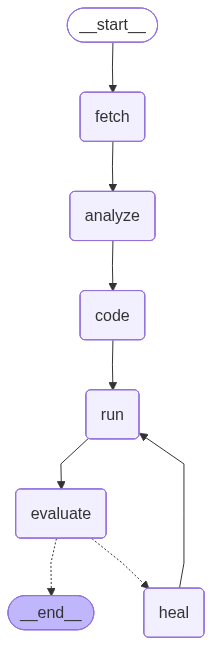

In [13]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## 🚀 Step 9: Run the Agent

The `solve_problem` function is the main entry point. It sets up the initial state and invokes the full agent graph.

> **Parameters:**
> - `problem_url` — Codeforces URL of the problem
> - `difficulty` — problem rating (used to decide which LLM to heal with, default = 1300)
> - `language` — `"cpp"` or `"python"`(default = `"cpp"`)


In [14]:
def solve_problem(problem_url: str, difficulty: int = 1300, language: str = "cpp"):
    initial_state: AgentState = {
        "problem_url": problem_url,
        "problem_id": problem_url.rstrip("/").split("/")[-1],
        "difficulty": difficulty,
        "language": language,
        "attempt_count": 0,
        "status": "pending",
        "messages": [],
    }

    final_state = graph.invoke(initial_state)
    return final_state

## 📂 Step 10: Batch Evaluation

We run the agent over a CSV file (`problems.csv`) that contains a list of problem URLs and their ratings. Results are saved to `agent_run_results.csv`.

The CSV format expected:
```
Problems,ratings
https://codeforces.com/problemset/problem/1559/B,1500
https://codeforces.com/problemset/problem/1562/D,1700
```

> Set `NUM_PROBLEMS` to a small number first to verify everything works, then increase.

In [15]:
import pandas as pd
import time

NUM_PROBLEMS = 24            # increase this to run on more problems
df = pd.read_csv("problems.csv")
df = df.head(NUM_PROBLEMS)

results = []

for _, row in df.iterrows():
    url = row["Problems"]
    rating = row["ratings"]

    print(f"\n🔍 Running: {url} | rating={rating}")
    time.sleep(20)

    # Handles API limitation bottleneck
    c = 0
    while True:
        try:
            result_state = solve_problem(url, difficulty=int(rating), language="cpp")
            break
        except Exception as e:
            err = str(e).lower()

            retryable = any(x in err for x in [
                "429",
                "503",
                "unavailable",
                "high demand",
                "try again later",
                "rate limit",
                "resource exhausted",
                "quota",
                "too many requests",
                "tpm",
                "usage limit"
            ])

            if retryable and c < 3:
                c += 1
                print(f"⏳ Temporary API issue for {url}. Waiting 60 seconds before retry {c}/3...")
                print(f"⚠️ Error: {e}")
                time.sleep(60)
            else:
                print(f"⏭️ Skipping question after {c} retries: {url}")
                result_state = {
                    "status": "skipped",
                    "attempt_count": 0,
                    "run_result": {
                        "passed": False,
                        "details": f"Skipped due to repeated API issues: {e}"
                    },
                    "problem_title": "",
                    "code": "",
                }
                break

    status = result_state.get("status")
    attempts = result_state.get("attempt_count")
    run_result = result_state.get("run_result", {})

    emoji = "✅" if run_result.get("passed") else "❌"
    print(f"{emoji} Final status: {status} | Attempts: {attempts}")
    print(f"   Run result: {run_result.get('details', 'N/A')}")

    results.append({
        "url": url,
        "rating": rating,
        "title": result_state.get("problem_title", ""),
        "status": status,
        "attempt_count": attempts,
        "passed": run_result.get("passed", False),
        "details": run_result.get("details", ""),
        "final_code": result_state.get("code", ""),
    })


🔍 Running: https://codeforces.com/problemset/problem/1511/C | rating=1100
✅ Final status: done | Attempts: 1
   Run result: All sample tests passed

🔍 Running: http://codeforces.com/problemset/problem/1610/B | rating=1100
✅ Final status: done | Attempts: 1
   Run result: All sample tests passed

🔍 Running: https://codeforces.com/problemset/problem/414/B | rating=1400
✅ Final status: done | Attempts: 1
   Run result: All sample tests passed

🔍 Running: https://codeforces.com/problemset/problem/1167/C | rating=1400
✅ Final status: done | Attempts: 1
   Run result: All sample tests passed

🔍 Running: https://codeforces.com/problemset/problem/1350/B | rating=1400
✅ Final status: done | Attempts: 1
   Run result: All sample tests passed

🔍 Running: https://codeforces.com/problemset/problem/845/C | rating=1500
✅ Final status: done | Attempts: 0
   Run result: All sample tests passed

🔍 Running: https://codeforces.com/problemset/problem/1101/C | rating=1500
❌ Final status: failed | Attempts:

## 📈 Step 11: Save and Summarize Results

In [16]:
results_df = pd.DataFrame(results)
results_df.to_csv("agent_run_results.csv", index=False)

print("\n📊 Batch summary:")
print(results_df[["url", "rating", "status", "attempt_count", "passed"]])

# Quick stats
total = len(results_df)
passed = results_df["passed"].sum()
print(f"\n✅ Solved: {passed}/{total} ({100*passed//total if total else 0}%)")

if len(results) > 0:
    print("\n📝 First problem final code preview:\n")
    print(results[0]["final_code"][:500], "..." if len(results[0]["final_code"]) > 500 else "")


📊 Batch summary:
                                                 url  rating  status  \
0   https://codeforces.com/problemset/problem/1511/C    1100    done   
1    http://codeforces.com/problemset/problem/1610/B    1100    done   
2    https://codeforces.com/problemset/problem/414/B    1400    done   
3   https://codeforces.com/problemset/problem/1167/C    1400    done   
4   https://codeforces.com/problemset/problem/1350/B    1400    done   
5    https://codeforces.com/problemset/problem/845/C    1500    done   
6   https://codeforces.com/problemset/problem/1101/C    1500  failed   
7    https://codeforces.com/problemset/problem/891/A    1500    done   
8   https://codeforces.com/problemset/problem/1084/C    1500    done   
9   https://codeforces.com/problemset/problem/1106/D    1500    done   
10  https://codeforces.com/problemset/problem/1475/E    1600    done   
11  https://codeforces.com/problemset/problem/1610/C    1600    done   
12  https://codeforces.com/problemset/problem/

---

## ✅ Summary

Here's what we built:

| Component | Technology | Purpose |
|-----------|------------|---------|
| Agent framework | LangGraph `StateGraph` | Stateful, cyclic workflow |
| LLM (planning + coding) | Gemini Flash Lite | Fast, cheap first attempt |
| LLM (healing) | Gemini Flash | Stronger debugging model |
| Code execution | `subprocess` + `g++` | Local sandbox testing |
| Problem data | JSON cache | Fast, offline problem loading |
| Self-healing | `heal → run` loop | Up to 3 automated fix attempts |

### What Makes This Architecture Robust?

1. **Separation of concerns** — each node has exactly one job, making the system easy to extend
2. **Feedback-driven healing** — the debug LLM sees the exact failure, not just "it failed"
3. **Adaptive model selection** — harder problems and more attempts trigger the stronger model
4. **Graceful failure** — the agent never loops forever; it gives up cleanly after `MAX_ATTEMPTS`
5. **Full traceability** — the `messages` list in `AgentState` records every LLM interaction

---
